In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [6]:
ls

In [7]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

In [8]:
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [9]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
gender_train = pd.get_dummies(train['Sex'], drop_first=True)
gender_test = pd.get_dummies(test['Sex'], drop_first=True)

In [11]:
for i,item in enumerate(gender_train['male']):
    if item == True:
        gender_train['male'][i]=1
    else:
        gender_train['male'][i]=0

for i,item in enumerate(gender_test['male']):
    if item == True:
        gender_test['male'][i]=1
    else:
        gender_test['male'][i]=0

/tmp/ipykernel_73/3818246992.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  gender_train['male'][i]=1
/tmp/ipykernel_73/3818246992.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a fut

In [12]:
train.drop('Sex', axis=1, inplace=True)
test.drop('Sex', axis=1, inplace=True)

In [13]:
train = pd.concat([train, gender_train], axis=1)
test = pd.concat([test, gender_test], axis=1)

In [14]:
train['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [15]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
 11  male         891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
names_train = train['Name'].apply(lambda x: x.split(',')[1])
names_test = test['Name'].apply(lambda x: x.split(',')[1])

In [17]:
names_train = names_train.apply(lambda x: x.split('.')[0].lstrip())
names_test = names_test.apply(lambda x: x.split('.')[0].lstrip())

In [18]:
train.drop(['Name'], axis=1, inplace=True)
test.drop(['Name'], axis=1, inplace=True)

In [19]:
names_train.value_counts()

Name
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [20]:
names_test.value_counts()

Name
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [21]:
names_train_dummies = pd.get_dummies(names_train, drop_first=True)
names_test_dummies = pd.get_dummies(names_test, drop_first=True)

In [22]:
train = pd.concat([train, names_train_dummies], axis=1)
test = pd.concat([test, names_test_dummies], axis=1)

For Cabin the logic is to make each Cabin entry unique in numerical form without using dummies since it would create a lot of variables.

In [23]:
train['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [24]:
cabins = train['Cabin']

In [25]:
cabins_test = test['Cabin']

In [26]:
cabins = cabins.astype(str).apply(lambda x: x.split(' ')[0])

In [27]:
cabins_test = cabins_test.astype(str).apply(lambda x: x.split(' ')[0])

In [28]:
cabins.value_counts()

Cabin
nan     687
G6        4
F         4
C23       4
B96       4
       ... 
E17       1
A24       1
C50       1
B42       1
C148      1
Name: count, Length: 146, dtype: int64

In [29]:
mx=0
for index,i in enumerate(cabins):
    # print(i)
    if i != 'nan':
        # print(type(i),i)
        letter = i[0]
        number = i[1:]
        # print(letter)
        # print(number)
        lm = ord(letter)-64
        if number == '':
            number = 0
        number = int(number)
        # print(lm, number)
        if number > mx:
            mx = number

for index,i in enumerate(cabins):
    # print(i)
    if i != 'nan':
        # print(type(i),i)
        letter = i[0]
        number = i[1:]
        # print(letter)
        # print(number)
        lm = ord(letter)-64
        if number == '':
            number = 0
        number = int(number)
        # print(lm, number)
        cabins[index]=((number+1)*(mx+1))+lm

In [30]:
for index,i in enumerate(cabins_test):
    # print(i)
    if i != 'nan':
        # print(type(i),i)
        letter = i[0]
        number = i[1:]
        # print(letter)
        # print(number)
        lm = ord(letter)-64
        if number == '':
            number = 0
        number = int(number)
        # print(lm, number)
        cabins_test[index]=((number+1)*(mx+1))+lm

In [31]:
train['Cabin'].value_counts()

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [32]:
cabins.value_counts()

Cabin
nan      687
1050       4
155        4
3579       4
14455      4
        ... 
2687       1
3726       1
7602       1
6409       1
22204      1
Name: count, Length: 146, dtype: int64

In [33]:
cabins_test.value_counts()

Cabin
nan      327
155        4
8644       3
6856       2
17436      2
        ... 
6260       1
1195       1
6113       1
5815       1
15797      1
Name: count, Length: 74, dtype: int64

In [34]:
train.drop(['Cabin'], axis=1, inplace=True)
train = pd.concat([train, cabins], axis=1)

In [35]:
train.head(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Embarked,male,...,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess,Cabin
0,1,0,3,22.0,1,0,A/5 21171,7.2500,S,1,...,False,False,False,True,False,False,False,False,False,nan
1,2,1,1,38.0,1,0,PC 17599,71.2833,C,0,...,False,False,False,False,True,False,False,False,False,12817


In [36]:
test.drop(['Cabin'], axis=1, inplace=True)
test = pd.concat([test, cabins_test], axis=1)

In [37]:
train.head(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,Embarked,male,...,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess,Cabin
0,1,0,3,22.0,1,0,A/5 21171,7.2500,S,1,...,False,False,False,True,False,False,False,False,False,nan
1,2,1,1,38.0,1,0,PC 17599,71.2833,C,0,...,False,False,False,False,True,False,False,False,False,12817


In [38]:
train['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [39]:
test['Embarked'].value_counts()

Embarked
S    270
C    102
Q     46
Name: count, dtype: int64

In [40]:
emb_dummies_train = pd.get_dummies(train['Embarked'], drop_first=True)
emb_dummies_test = pd.get_dummies(test['Embarked'], drop_first=True)

In [41]:
train.drop('Embarked', axis=1, inplace=True)
test.drop('Embarked', axis=1, inplace=True)

In [42]:
train = pd.concat([train, emb_dummies_train], axis=1)
test = pd.concat([test, emb_dummies_test], axis=1)

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
train.head(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare,male,Col,...,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess,Cabin,Q,S
0,1,0,3,22.0,1,0,A/5 21171,7.2500,1,False,...,False,True,False,False,False,False,False,nan,False,True
1,2,1,1,38.0,1,0,PC 17599,71.2833,0,False,...,False,False,True,False,False,False,False,12817,False,False


Even though All Cabin values except NAN has been converted to int but since there are lot of NaN values so dropping that column.

In [45]:
train_ = train.drop(['Ticket', 'Cabin'], axis=1)
test_ = test.drop(['Ticket','Cabin'], axis=1)

In [46]:
train_.head(1)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Col,Don,...,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess,Q,S
0,1,0,3,22.0,1,0,7.25,1,False,False,...,False,False,True,False,False,False,False,False,False,True


In [47]:
# Below is not working as there are still NA or inf values
# train_= train_.astype(int)

In [48]:
train_ = train_.replace({True:1, False:0})

/tmp/ipykernel_73/3897471911.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_ = train_.replace({True:1, False:0})


In [49]:
train_.head()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,male,Col,Don,...,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess,Q,S
0,1,0,3,22.0,1,0,7.2500,1,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2,1,1,38.0,1,0,71.2833,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,3,1,3,26.0,0,0,7.9250,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,1,35.0,1,0,53.1000,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,5,0,3,35.0,0,0,8.0500,1,0,0,...,0,0,1,0,0,0,0,0,0,1


In [50]:
test_ = test_.replace({True:1, False:0})

/tmp/ipykernel_73/1638165975.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_ = test_.replace({True:1, False:0})


In [51]:
test_.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Dona,Dr,Master,Miss,Mr,Mrs,Ms,Rev,Q,S
0,892,3,34.5,0,0,7.8292,1,0,0,0,0,1,0,0,0,1,0
1,893,3,47.0,1,0,7.0000,0,0,0,0,0,0,1,0,0,0,1
2,894,2,62.0,0,0,9.6875,1,0,0,0,0,1,0,0,0,1,0
3,895,3,27.0,0,0,8.6625,1,0,0,0,0,1,0,0,0,0,1
4,896,3,22.0,1,1,12.2875,0,0,0,0,0,0,1,0,0,0,1


Modelling Below:

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
log_model = LogisticRegression()

In [54]:
train_['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [55]:
test_.head(1)

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Dona,Dr,Master,Miss,Mr,Mrs,Ms,Rev,Q,S
0,892,3,34.5,0,0,7.8292,1,0,0,0,0,1,0,0,0,1,0


In [56]:
# test_['Survived'].value_counts()

Dropping all remaining NA values

In [57]:
train_.shape

(891, 26)

In [58]:
test_.shape

(418, 17)

In [59]:
train_.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'male', 'Col', 'Don', 'Dr', 'Jonkheer', 'Lady', 'Major', 'Master',
       'Miss', 'Mlle', 'Mme', 'Mr', 'Mrs', 'Ms', 'Rev', 'Sir', 'the Countess',
       'Q', 'S'],
      dtype='object')

In [60]:
test_.columns

Index(['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'male',
       'Dona', 'Dr', 'Master', 'Miss', 'Mr', 'Mrs', 'Ms', 'Rev', 'Q', 'S'],
      dtype='object')

In [61]:
# # For Test
# extra_cols_test = ['Col','Don','Jonkheer','Lady','Major','Mlle','Mme','Sir','the Countess']

# # For Train
# extra_cols_train = ['Dona']

In [128]:
train__=train_

In [129]:
test__=test_

In [130]:
# for i in extra_cols_train:
#     train__[i] = pd.Series([0]*train__.shape[0])

In [131]:
# train__.columns

In [132]:
# for i in extra_cols_test:
#     test__[i] = pd.Series([0]*test__.shape[0])

In [133]:
train__.dropna(axis=0)
test__.dropna(axis=0)

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Dona,Dr,Master,Miss,Mr,Mrs,Ms,Rev,Q,S
0,892,3,34.5,0,0,7.8292,1,0,0,0,0,1,0,0,0,1,0
1,893,3,47.0,1,0,7.0000,0,0,0,0,0,0,1,0,0,0,1
2,894,2,62.0,0,0,9.6875,1,0,0,0,0,1,0,0,0,1,0
3,895,3,27.0,0,0,8.6625,1,0,0,0,0,1,0,0,0,0,1
4,896,3,22.0,1,1,12.2875,0,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
409,1301,3,3.0,1,1,13.7750,0,0,0,0,1,0,0,0,0,0,1
411,1303,1,37.0,1,0,90.0000,0,0,0,0,0,0,1,0,0,1,0
412,1304,3,28.0,0,0,7.7750,0,0,0,0,1,0,0,0,0,0,1
414,1306,1,39.0,0,0,108.9000,0,1,0,0,0,0,0,0,0,0,0


In [134]:
train__.shape

(891, 26)

In [135]:
test__.shape

(418, 17)

In [136]:
train_features = train__.columns.tolist()

In [137]:
test__ = test__.reindex(columns = train_features, fill_value=0)

In [138]:
test_features = test__.columns.tolist()

In [139]:
test__.drop('Survived', axis=1, inplace=True)

In [140]:
train__ = train__.reindex(columns = test_features, fill_value=0)

In [141]:
train__.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   891 non-null    int64  
 1   Survived      891 non-null    int64  
 2   Pclass        891 non-null    int64  
 3   Age           714 non-null    float64
 4   SibSp         891 non-null    int64  
 5   Parch         891 non-null    int64  
 6   Fare          891 non-null    float64
 7   male          891 non-null    int64  
 8   Col           891 non-null    int64  
 9   Don           891 non-null    int64  
 10  Dr            891 non-null    int64  
 11  Jonkheer      891 non-null    int64  
 12  Lady          891 non-null    int64  
 13  Major         891 non-null    int64  
 14  Master        891 non-null    int64  
 15  Miss          891 non-null    int64  
 16  Mlle          891 non-null    int64  
 17  Mme           891 non-null    int64  
 18  Mr            891 non-null    

Below the mean needs to be recalculated only for non nan values and then populated 

In [142]:
train__['Age'] = train__['Age'].fillna(train__['Age'].mean())

In [143]:
test__['Age'] = test__['Age'].fillna(test__['Age'].mean())

In [144]:
train__.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   891 non-null    int64  
 1   Survived      891 non-null    int64  
 2   Pclass        891 non-null    int64  
 3   Age           891 non-null    float64
 4   SibSp         891 non-null    int64  
 5   Parch         891 non-null    int64  
 6   Fare          891 non-null    float64
 7   male          891 non-null    int64  
 8   Col           891 non-null    int64  
 9   Don           891 non-null    int64  
 10  Dr            891 non-null    int64  
 11  Jonkheer      891 non-null    int64  
 12  Lady          891 non-null    int64  
 13  Major         891 non-null    int64  
 14  Master        891 non-null    int64  
 15  Miss          891 non-null    int64  
 16  Mlle          891 non-null    int64  
 17  Mme           891 non-null    int64  
 18  Mr            891 non-null    

In [145]:
test__.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   418 non-null    int64  
 1   Pclass        418 non-null    int64  
 2   Age           418 non-null    float64
 3   SibSp         418 non-null    int64  
 4   Parch         418 non-null    int64  
 5   Fare          417 non-null    float64
 6   male          418 non-null    int64  
 7   Col           418 non-null    int64  
 8   Don           418 non-null    int64  
 9   Dr            418 non-null    int64  
 10  Jonkheer      418 non-null    int64  
 11  Lady          418 non-null    int64  
 12  Major         418 non-null    int64  
 13  Master        418 non-null    int64  
 14  Miss          418 non-null    int64  
 15  Mlle          418 non-null    int64  
 16  Mme           418 non-null    int64  
 17  Mr            418 non-null    int64  
 18  Mrs           418 non-null    

In [146]:
test__['Fare'] = test__['Fare'].fillna(test__['Fare'].mean())

In [147]:
X_train = train__.drop('Survived', axis=1)

In [148]:
X_test = test__

In [149]:
y_train = train__['Survived']

In [ ]:
log_model.fit(X_train, y_train)

In [ ]:
preds = log_model.predict(X_test)

In [ ]:
preds

In [84]:
train2 = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test2 = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [85]:
train2.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [86]:
gender_train2 = pd.get_dummies(train2['Sex'], drop_first=True)
gender_test2 = pd.get_dummies(test2['Sex'], drop_first=True)

In [87]:
train = pd.concat([train2, gender_train2], axis=1)
test = pd.concat([test2, gender_test2], axis=1)

In [88]:
train2.drop('Sex', axis=1, inplace=True)
test2.drop('Sex', axis=1, inplace=True)

In [89]:
emb_dummies_train2 = pd.get_dummies(train2['Embarked'], drop_first=True)
emb_dummies_test2 = pd.get_dummies(test2['Embarked'], drop_first=True)
train2.drop('Embarked', axis=1, inplace=True)
test2.drop('Embarked', axis=1, inplace=True)
train2 = pd.concat([train2, emb_dummies_train2], axis=1)
test2 = pd.concat([test2, emb_dummies_test2], axis=1)

In [90]:
train2.head(2)

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,False,False


In [91]:
train2.drop(['Name','Ticket','Cabin'], axis=1, inplace=True)
test2.drop(['Name','Ticket','Cabin'], axis=1, inplace=True)

In [92]:
train2.head(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Q,S
0,1,0,3,22.0,1,0,7.2500,False,True
1,2,1,1,38.0,1,0,71.2833,False,False


In [93]:
train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Q            891 non-null    bool   
 8   S            891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB


In [94]:
test2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Age          332 non-null    float64
 3   SibSp        418 non-null    int64  
 4   Parch        418 non-null    int64  
 5   Fare         417 non-null    float64
 6   Q            418 non-null    bool   
 7   S            418 non-null    bool   
dtypes: bool(2), float64(2), int64(4)
memory usage: 20.5 KB


In [95]:
test2['Fare'] = test2['Fare'].fillna(test2['Fare'].mean())
test2['Age'] = test2['Age'].fillna(test2['Age'].mean())
train2['Age'] = train2['Age'].fillna(train2['Age'].mean())

In [96]:
train2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          891 non-null    float64
 4   SibSp        891 non-null    int64  
 5   Parch        891 non-null    int64  
 6   Fare         891 non-null    float64
 7   Q            891 non-null    bool   
 8   S            891 non-null    bool   
dtypes: bool(2), float64(2), int64(5)
memory usage: 50.6 KB


In [97]:
test2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Age          418 non-null    float64
 3   SibSp        418 non-null    int64  
 4   Parch        418 non-null    int64  
 5   Fare         418 non-null    float64
 6   Q            418 non-null    bool   
 7   S            418 non-null    bool   
dtypes: bool(2), float64(2), int64(4)
memory usage: 20.5 KB


In [98]:
X_train2 = train2.drop('Survived', axis=1)
X_test2 = test2
y_train2 = train2['Survived']

In [ ]:
log_model2 = LogisticRegression()
log_model2.fit(X_train2, y_train2)

In [ ]:
y_pred = log_model2.predict(X_test2)

In [ ]:
y_pred

In [ ]:
y_pred.shape

Comparing Both Models output

In [ ]:
np.sum(y_pred!=preds)

In [ ]:
test__.head(1)

In [ ]:
preds1 = pd.DataFrame(test__['PassengerId'])

In [ ]:
preds1['Survived'] = preds

In [ ]:
preds1['Survived'].value_counts()

In [ ]:
preds1.to_csv('Predictions1.csv', index=False)

In [ ]:
preds2 = pd.DataFrame(test__['PassengerId'])

In [ ]:
preds2['Survived'] = y_pred

In [ ]:
preds2['Survived'].value_counts()

In [ ]:
preds2.to_csv('Predictions2.csv', index=False)

In [99]:
from sklearn.ensemble import RandomForestClassifier

In [100]:
rfc = RandomForestClassifier(n_estimators = 500)

In [ ]:
rfc.fit(X_train, y_train)

In [ ]:
pred3 = rfc.predict(X_test)

In [ ]:
pred3

In [ ]:
preds3 = pd.DataFrame(X_test['PassengerId'])

In [ ]:
preds3['Survived'] = pred3

In [ ]:
preds3['Survived'].value_counts()

In [ ]:
preds3.to_csv('Predictions_RFC_500.csv', index=False)

In [150]:
X_train.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Col,Don,Dr,...,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess,Q,S
0,1,3,22.0,1,0,7.2500,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2,1,38.0,1,0,71.2833,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,3,3,26.0,0,0,7.9250,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,35.0,1,0,53.1000,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,5,3,35.0,0,0,8.0500,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [151]:
X_train['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [152]:
features = ['Pclass', 'SibSp', 'Parch']

In [153]:
X_train.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Col,Don,Dr,...,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir,the Countess,Q,S
0,1,3,22.0,1,0,7.2500,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,2,1,38.0,1,0,71.2833,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,3,3,26.0,0,0,7.9250,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,4,1,35.0,1,0,53.1000,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,5,3,35.0,0,0,8.0500,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [154]:
X_dummies = pd.get_dummies(X_train[features])
X_test_dummies = pd.get_dummies(X_test[features])

In [155]:
X_train.drop(features, axis = 1, inplace = True)
X_test.drop(features, axis = 1, inplace = True)

In [156]:
X_train = pd.concat([X_train, X_dummies], axis = 1)
X_test = pd.concat([X_test, X_test_dummies], axis = 1)

In [107]:
rfc2 = RandomForestClassifier(n_estimators = 100)

In [ ]:
rfc2.fit(X_train, y_train)

In [ ]:
pred4 = rfc2.predict(X_test)

In [ ]:
preds4 = pd.DataFrame(X_test['PassengerId'])

In [ ]:
preds4['Survived'] = pred4

In [ ]:
preds4['Survived'].value_counts()

In [ ]:
preds4.to_csv('Predictions2_RFC_100.csv', index=False)

KNN

In [108]:
from sklearn.neighbors import KNeighborsClassifier

In [157]:
y_train.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

In [159]:
error_rate = []
k = [1,2,5,10]
for i in k:
    knn = KNeighborsClassifier(i)
    knn.fit(X_train, y_train)
    predictions = knn.predict(X_train)
    error_rate.append(np.mean(predictions!=y_train))

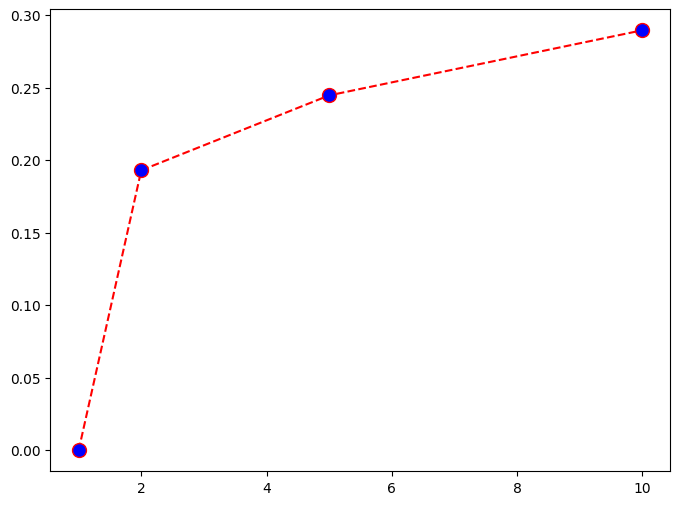

In [161]:
plt.figure(figsize=(8,6))
plt.plot(k, error_rate, linestyle = '--', color='red', marker='o', markerfacecolor='blue', markersize=10)


In [162]:
knn = KNeighborsClassifier(1)
knn.fit(X_train, y_train)
preds5 = knn.predict(X_test)

In [165]:
pred5 = pd.DataFrame(X_test['PassengerId'])

In [166]:
pred5['Survived'] = preds5

In [167]:
pred5['Survived'].value_counts()

Survived
0    292
1    126
Name: count, dtype: int64

In [168]:
pred5.to_csv('Predictions_KNN_with_k1.csv', index=False)